# Explore here

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# carga de datos
url = "https://raw.githubusercontent.com/4GeeksAcademy/linear-regression-project-tutorial/main/medical_insurance_cost.csv"
df = pd.read_csv(url)

# guardar archivo
path = "data/raw"
if not os.path.exists(path):
    os.makedirs(path)
df.to_csv("data/raw/medical_insurance_cost.csv", index=False)

In [16]:

#  Inspección Inicial 
print("Información General ")
print(df.info())
print("\n Primeras Filas del DataFrame ")
display(df.head())

Información General 
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None

 Primeras Filas del DataFrame 


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
#escala min-max
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

#se copia el dataframe para no modificar el original
total_data = df.copy()

# se convierten las variables categóricas a numéricas utilizando factorize
total_data["smoker_n"] = pd.factorize(total_data["smoker"])[0]
total_data["sex_n"] = pd.factorize(total_data["sex"])[0]
total_data["region_n"] = pd.factorize(total_data["region"])[0]

# se definen las variables numéricas a escalar
num_variables = ["age", "bmi", "children", "region_n", "smoker_n", "sex_n"]
scaled_features = scaler.fit_transform(total_data[num_variables])

total_data[num_variables] = scaled_features

# se definen las columnas escaladas y se crea un nuevo DataFrame con las características escaladas
scaled_columns = ["age", "bmi", "children", "region_n", "smoker_n", "sex_n"]

total_data_scal = pd.DataFrame(scaled_features, index=total_data.index, columns=scaled_columns)

# se añade la columna "charges" al DataFrame escalado
total_data_scal["charges"] = total_data["charges"]

total_data_scal.head()



,age,bmi,children,region_n,smoker_n,sex_n,charges
0,0.021739,0.321227,0.0,0.000000,0.0,0.0,16884.92400
1,0.000000,0.479150,0.2,0.333333,1.0,1.0,1725.55230
2,0.217391,0.458434,0.6,0.333333,1.0,1.0,4449.46200
3,0.326087,0.181464,0.0,0.666667,1.0,1.0,21984.47061
4,0.304348,0.347592,0.0,0.666667,1.0,1.0,3866.85520


In [34]:
import pandas as pd
# Corregido: SelectKBest con S y K mayúsculas (me salia un error de sintaxis) 
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split

# Separación de variables
# Asegúrarse de que total_data_scal ya sea todo numérico (sin texto)
X = total_data_scal.drop("charges", axis=1)
y = total_data_scal["charges"]

# se dividen los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Selección de variables, elegir las 4 mejores características según f_regression
selection_model = SelectKBest(f_regression, k=4) 
selection_model.fit(X_train, y_train)

# Obtener nombres y transformar
selected_columns = X_train.columns[selection_model.get_support()]
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns=selected_columns)
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns=selected_columns)

X_train_sel.head()

,age,bmi,children,smoker_n
0,0.608696,0.107345,0.4,1.0
1,0.630435,0.224913,0.0,1.0
2,0.739130,0.239440,0.0,1.0
3,0.456522,0.493947,1.0,1.0
4,0.782609,0.148238,0.6,1.0


In [35]:
# Mostrar las primeras filas del conjunto de prueba con las características seleccionadas
X_test_sel.head()

,age,bmi,children,smoker_n
0,0.586957,0.247915,0.4,1.0
1,0.391304,0.378262,0.0,1.0
2,1.000000,0.293920,0.0,0.0
3,0.608696,0.263250,0.6,1.0
4,0.021739,0.429379,0.0,0.0


In [24]:

# se añade la columna de precios ('charges') a nuestros conjuntos de variables seleccionadas
# se usa (.values) para asegurar que los datos encajen correctamente por posición
X_train_sel["charges"] = y_train.values
X_test_sel["charges"] = y_test.values

# Guardamos los conjuntos de entrenamiento y prueba en archivos CSV
X_train_sel.to_csv("../data/processed/clean_train.csv", index = False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index = False)

## Modelo de regresion lineal

In [36]:
# cargamos los archivos para asegurarnos de que se guardaron correctamente

train_data = pd.read_csv("../data/processed/clean_train.csv")
test_data = pd.read_csv("../data/processed/clean_test.csv")

train_data.head()

,age,bmi,children,smoker_n,charges
0,0.608696,0.107345,0.4,1.0,9193.83850
1,0.630435,0.224913,0.0,1.0,8534.67180
2,0.739130,0.239440,0.0,1.0,27117.99378
3,0.456522,0.493947,1.0,1.0,8596.82780
4,0.782609,0.148238,0.6,1.0,12475.35130


## Visualizacion

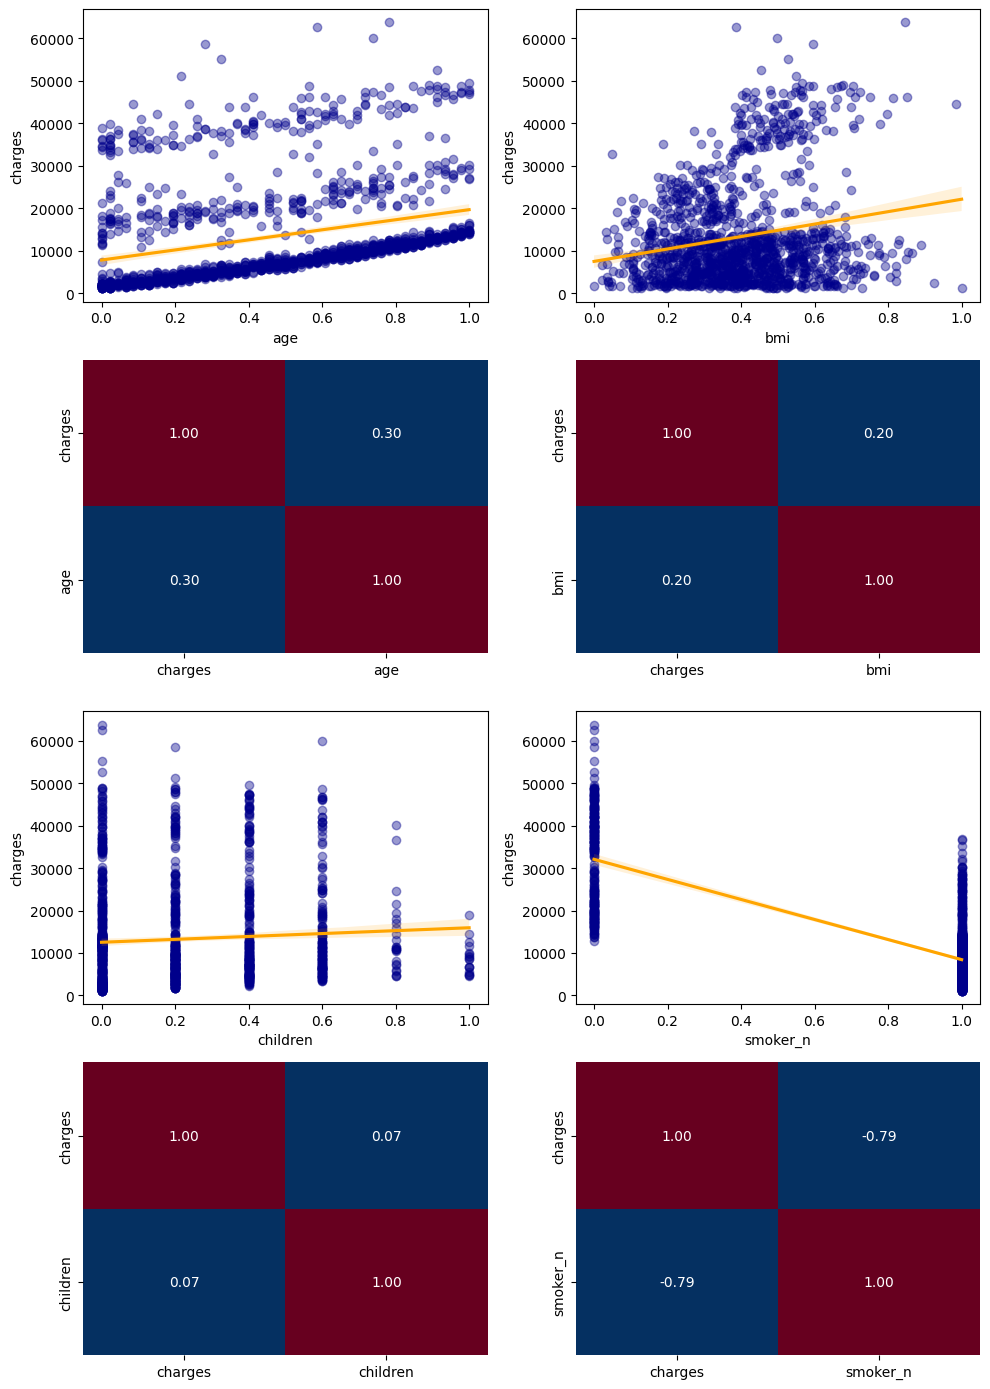

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configuración de estilo para los gráficos
fig, axis = plt.subplots(4, 2, figsize = (10, 14))

# Configuración de colores
color_puntos = "darkblue"
color_linea = "orange"
mapa_color = "RdBu_r"

# Gráfico: Age
sns.regplot(data = total_data, x = "age", y = "charges", ax = axis[0, 0], 
            scatter_kws={"color": color_puntos, "alpha": 0.4}, line_kws={"color": color_linea})
sns.heatmap(total_data[["charges", "age"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False, cmap=mapa_color)

# Gráfico: BMI (Body Mass Index)
sns.regplot(data = total_data, x = "bmi", y = "charges", ax = axis[0, 1], 
            scatter_kws={"color": color_puntos, "alpha": 0.4}, line_kws={"color": color_linea})
sns.heatmap(total_data[["charges", "bmi"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False, cmap=mapa_color)

# Gráfico: Children
sns.regplot(data = total_data, x = "children", y = "charges", ax = axis[2, 0], 
            scatter_kws={"color": color_puntos, "alpha": 0.4}, line_kws={"color": color_linea})
sns.heatmap(total_data[["charges", "children"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0], cbar = False, cmap=mapa_color)

# Gráfico: Smoker
sns.regplot(data = total_data, x = "smoker_n", y = "charges", ax = axis[2, 1], 
            scatter_kws={"color": color_puntos, "alpha": 0.4}, line_kws={"color": color_linea})
sns.heatmap(total_data[["charges", "smoker_n"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 1], cbar = False, cmap=mapa_color)

plt.tight_layout()
plt.show()

Tras analizar las visualizaciones, se puede llagar a la concusion de que el estatus de fumador (smoker) y la edad (age) son los predictores más fuertes para el costo del seguro. 



In [54]:
# SEPARACIÓN DE CARACTERÍSTICAS (X) Y OBJETIVO (y) 

# Para el conjunto de entrenamiento (Train):

# X_train = Todas las columnas EXCEPTO el costo (nuestros predictores)
X_train = train_data.drop(["charges"], axis = 1)

# y_train = Solo la columna de costos (lo que el modelo debe aprender a predecir)
y_train = train_data["charges"]

# Para el conjunto de prueba (Test):
# Hacemos exactamente lo mismo para tener datos limpios con los que evaluar después
X_test = test_data.drop(["charges"], axis = 1)
y_test = test_data["charges"]

In [55]:
# INSTANCIACIÓN DEL MODELO
from sklearn.linear_model import LinearRegression

# Creamos una instancia del modelo de regresión lineal
model = LinearRegression()

# entrenamos el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


-fit_intercept: - True: significa que el modelo calculó un "punto de partida" o constante.

-copy_X: - True: Indica que el modelo hizo una copia de los datos para trabajar, así que las variables originales en X_train no fueron alteradas ni destruidas durante el entrenamiento.

-n_jobs: - None: Significa que usó un solo núcleo del procesador.

-positive: - False: Esto permite que el modelo tenga coeficientes negativos (si una variable hiciera que el precio bajara, el modelo tiene libertad para calcularlo).

In [56]:
# PREDICCIÓN CON EL MODELO ENTRENADO
# Aquí usamos el modelo para predecir los costos en el conjunto de prueba (X_test) y luego mostramos las predicciones
y_pred = model.predict(X_test)
y_pred

# El intercepto (a) y los coeficientes (b1, b2, ...) nos indican cómo el modelo está utilizando cada variable para hacer predicciones
print(f"Intercep (a): {model.intercept_}")
print(f"Coefficients (b1, b2): {model.coef_}")

print(f"Primeras 5 predicciones: {y_pred[:5]}")

Intercep (a): 21390.67860757516
Coefficients (b1, b2): [ 11825.27326582  12174.01619773   2135.99985473 -23653.21164629]
Primeras 5 predicciones: [ 8550.90921341  6969.71599759 36794.13661808  9421.86824203
 26875.01095777]


In [57]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluamos el rendimiento del modelo utilizando métricas comunes para regresión: MSE (Mean Squared Error) y R2 Score
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 33981653.95019776
R2 Score: 0.7811147722517886


In [58]:
import numpy as np
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

RMSE: 5829.378521780667


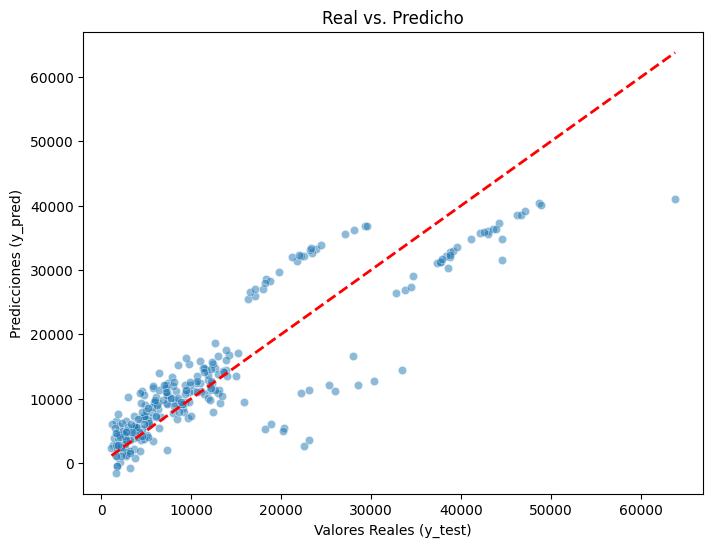

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de dispersión para comparar los valores reales (y_test) con las predicciones del modelo (y_pred)
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title("Real vs. Predicho")
plt.xlabel("Valores Reales (y_test)")
plt.ylabel("Predicciones (y_pred)")
plt.show()

El modelo es confiable para clientes generales, pero tiende a ser más impreciso con los casos de alto costo (fumadores o riesgos altos). Pero con un 78% de precisión (R2), es una buena herramienta  para estimar precios de forma automática. 